In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
import warnings
warnings.filterwarnings('ignore')

if os.getcwd().endswith("notebooks"):
    os.chdir("..")
    
sys.path.append(os.getcwd())

from src.components.data_ingestion import DataIngestion
from src.components.data_transformation import DataTransformation
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline


## Experiment 1: Handling Imbalance using SMOTE

In [4]:
# Data Ingestion
ingestion = DataIngestion()
train_path, test_path = ingestion.initiate_data_ingestion()

# Data Transformation
transformation = DataTransformation()
train_arr, test_arr, _ = transformation.initiate_data_transformation(train_path, test_path)


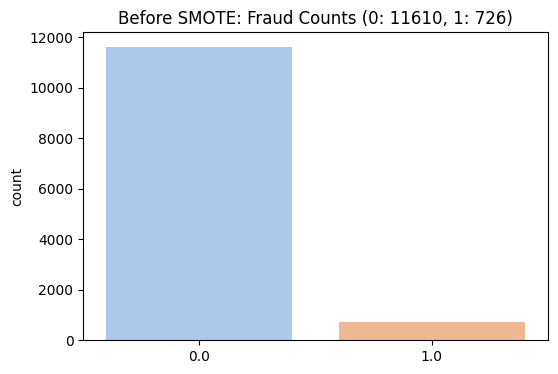

Percentage of Fraud Cases: 5.885214007782101 %


In [ ]:
# Class Imbalance

X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]
X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='pastel')
plt.title(f"Before SMOTE: Fraud Counts (0: {sum(y_train==0)}, 1: {sum(y_train==1)})")
plt.show()

print("Percentage of Fraud Cases:", (sum(y_train==1)/len(y_train))*100, "%")


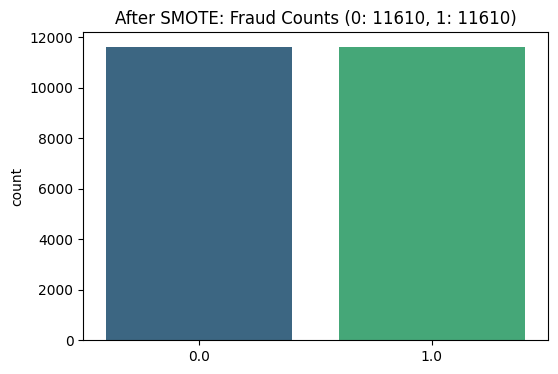

Percentage of Fraud Cases After SMOTE: 50.0 %


In [ ]:
# Applying SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title(f"After SMOTE: Fraud Counts (0: {sum(y_train_smote==0)}, 1: {sum(y_train_smote==1)})")
plt.show()

print("Percentage of Fraud Cases After SMOTE:", (sum(y_train_smote==1)/len(y_train_smote))*100, "%")


In [21]:
X_train_smote.shape[0]


23220

In [33]:
# ANN Architecture

model = Sequential()

# Layer 1: Input Layer
# units=64 means 64 neurons (Rule of thumb: input_dim/2)
# because we have 144 features after applying OneHotEncoding so 144/2 = nearby 64
# activation='relu': to zero the negative values and add non-linearity
model.add(Dense(units=64, activation='relu', input_dim=X_train_smote.shape[1]))
model.add(Dropout(0.3))

# Layer 2: Hidden Layer
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

# Layer 3: Output Layer
# units=1: we want only 1 value (Fraud or not)
# activation='sigmoid': Creates Probabilty for Output from 0 to 1
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,329 (44.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training with Viz. Logic
# Stop training if the loss does not improve for 5 consecutive epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_smote, y_train_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - accuracy: 0.7077 - loss: 0.5537 - val_accuracy: 0.8211 - val_loss: 0.5751
Epoch 2/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.7873 - loss: 0.4234 - val_accuracy: 0.8839 - val_loss: 0.4704
Epoch 3/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.8283 - loss: 0.3648 - val_accuracy: 0.8671 - val_loss: 0.4318
Epoch 4/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.8622 - loss: 0.3138 - val_accuracy: 0.9201 - val_loss: 0.3252
Epoch 5/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - accuracy: 0.8873 - loss: 0.2659 - val_accuracy: 0.9236 - val_loss: 0.2951
Epoch 6/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.9021 - loss: 0.2384 - val_accuracy: 0.9701 - val_loss: 0.1788
Epoch 7/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.9212 - loss: 0.2019 - val_accuracy: 0.9649 - val_loss: 0.1709
Epoch 8/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.9261 - loss: 0.1875 - 

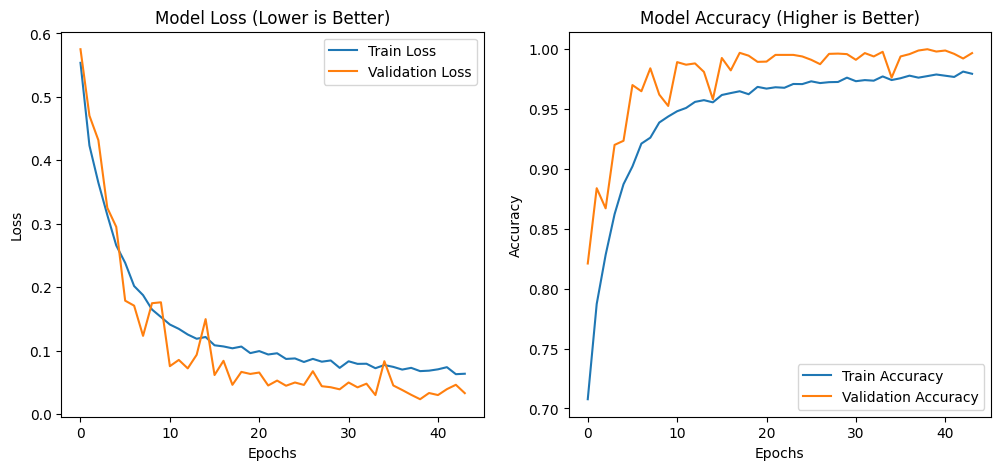

In [35]:
# Plotting Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Lower is Better)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (Higher is Better)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step


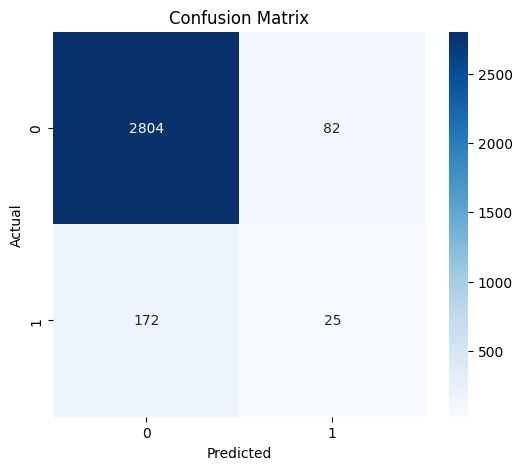

              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96      2886
         1.0       0.23      0.13      0.16       197

    accuracy                           0.92      3083
   macro avg       0.59      0.55      0.56      3083
weighted avg       0.90      0.92      0.91      3083



In [36]:
# Probability predictions
y_pred_prob = model.predict(X_test)

# Convert to 0 or 1 (Threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))


### Result: Recall Score for Fraud Case is very low (0.13). model is overfitting

## Experiment 2: Handling Imbalance using Class Weights

In [39]:
from sklearn.utils import class_weight

print("⚖️ Calculating Class Weights...")


⚖️ Calculating Class Weights...


In [ ]:
# Calculate Weights
# 'balanced' mode automatically counts that which class is less and it will increase weight for them
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Keras need dictionary format
weights_dict = {0: class_weights_vals[0], 1: class_weights_vals[1]}

print(f"Calculated Weights: {weights_dict}")
print(f"That means: Model's 1 Fraud mistake = {round(weights_dict[1]/weights_dict[0], 1)} Normal mistake.")


Calculated Weights: {0: np.float64(0.531266149870801), 1: np.float64(8.49586776859504)}
That means: Model's 1 Fraud mistake = 16.0 Normal mistake.


In [44]:
# Re-build Model
model_cw = Sequential()
model_cw.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model_cw.add(Dropout(0.3))
model_cw.add(Dense(units=32, activation='relu'))
model_cw.add(Dropout(0.3))
model_cw.add(Dense(units=1, activation='sigmoid'))
model_cw.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Train with Weights
history_cw = model_cw.fit(
    X_train, y_train, # using original data
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=weights_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6340 - loss: 0.8714 - val_accuracy: 0.5669 - val_loss: 0.6549
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.6285 - loss: 0.6166 - val_accuracy: 0.6345 - val_loss: 0.5271
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.6617 - loss: 0.5566 - val_accuracy: 0.7322 - val_loss: 0.4055
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.6737 - loss: 0.5223 - val_accuracy: 0.6293 - val_loss: 0.5167
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.6554 - loss: 0.5072 - val_accuracy: 0.6268 - val_loss: 0.4911


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
              precision    recall  f1-score   support

         0.0       0.98      0.54      0.70      2886
         1.0       0.11      0.87      0.20       197

    accuracy                           0.56      3083
   macro avg       0.55      0.71      0.45      3083
weighted avg       0.93      0.56      0.67      3083



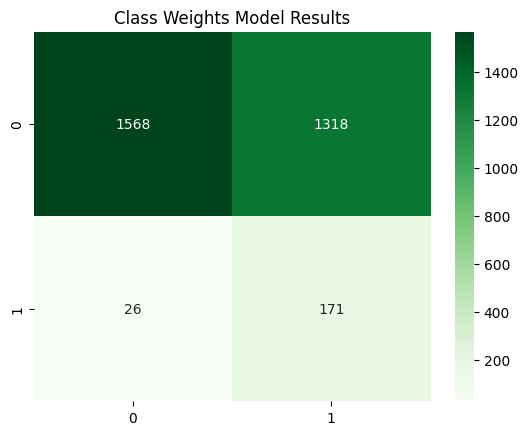

In [46]:
# Evaluate
y_pred_prob_cw = model_cw.predict(X_test)
y_pred_cw = (y_pred_prob_cw > 0.5).astype(int)

print(classification_report(y_test, y_pred_cw))

cm = confusion_matrix(y_test, y_pred_cw)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Class Weights Model Results')
plt.show()
